# Mathematics for AI — NumPy Companion Notebook

A hands-on companion to the *Mathematics for AI* book. Every concept here is something
you can **run, change, and re-run**. That is the whole point: read a little, compute a lot.

**How to use this notebook**
- Run each cell in order (Shift+Enter).
- After a cell runs, *change a number* and run it again. Predict the output before you look.
- The 🧪 **Try it yourself** cells are for you to fill in; solutions follow in a hidden-ish cell right below.

**Contents**
1. Scalars, Vectors, Matrices & Tensors
2. Vector Operations — Dot Product & Norm
3. Matrix Multiplication
4. Eigenvalues & Eigenvectors
5. Probability Fundamentals (by simulation)
6. Bayes' Theorem
7. Mean, Median, Mode
8. Variance & Standard Deviation
9. Correlation
10. The Normal Distribution
11. Gradients & Gradient Descent

In [1]:
# Setup — run this first
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)   # tidy printing
rng = np.random.default_rng(42)                   # reproducible randomness

print("NumPy version:", np.__version__)
print("Ready. Let's compute.")

NumPy version: 2.4.4
Ready. Let's compute.


---
## 1. Scalars, Vectors, Matrices & Tensors

The four objects of linear algebra differ only by how many **axes** of numbers they hold.
The number of axes is the **rank**. In NumPy, always check `.shape` and `.ndim`.

In [2]:
scalar = np.array(5)                     # rank 0 — no axes
vector = np.array([2, -1, 4])            # rank 1 — one axis
matrix = np.array([[1, 2, 3],
                   [4, 5, 6]])           # rank 2 — rows x columns
tensor = np.arange(24).reshape(2, 3, 4)  # rank 3 — a stack of matrices

for name, obj in [("scalar", scalar), ("vector", vector),
                  ("matrix", matrix), ("tensor", tensor)]:
    print(f"{name:7s} | ndim (rank) = {obj.ndim} | shape = {obj.shape}")

scalar  | ndim (rank) = 0 | shape = ()
vector  | ndim (rank) = 1 | shape = (3,)
matrix  | ndim (rank) = 2 | shape = (2, 3)
tensor  | ndim (rank) = 3 | shape = (2, 3, 4)


### Reading a real-world shape

A batch of 64 colour images, each 28×28 pixels with 3 (RGB) channels, is a **rank-4 tensor**
of shape `(64, 28, 28, 3)` — (batch, height, width, channels). Learning to read shapes at a
glance is a genuine day-one deep-learning skill.

In [3]:
batch_of_images = np.zeros((64, 28, 28, 3))
print("shape:", batch_of_images.shape)
print("rank :", batch_of_images.ndim)
print("total numbers stored:", batch_of_images.size)

shape: (64, 28, 28, 3)
rank : 4
total numbers stored: 150528


#### 🧪 Try it yourself
Create a rank-4 tensor representing a **colour video**: 30 frames, each 1080×1920 with 3 channels.
Print its shape and rank.

In [4]:
# Your turn — build the tensor and print shape + rank

In [5]:
# Solution
video = np.zeros((30, 1080, 1920, 3))
print("shape:", video.shape, "| rank:", video.ndim)

shape: (30, 1080, 1920, 3) | rank: 4


---
## 2. Vector Operations — Dot Product & Norm

Vectors of the same length add component-by-component and scale by a scalar. The **dot product**
collapses two vectors into a single number measuring how much they "agree". The **norm** is a
vector's length.

In [6]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print("a + b   =", a + b)          # element-wise addition
print("3 * a   =", 3 * a)          # scaling
print("a . b   =", np.dot(a, b))   # dot product -> 4 + 10 + 18 = 32
print("a @ b   =", a @ b)          # '@' is the dot/matmul operator
print("|(3,4)| =", np.linalg.norm(np.array([3, 4])))  # length = 5.0

a + b   = [5 7 9]
3 * a   = [3 6 9]
a . b   = 32
a @ b   = 32
|(3,4)| = 5.0


### The dot product as *agreement*

The dot product is large & positive when vectors point the same way, zero when perpendicular,
and negative when they point opposite ways. That is why it powers similarity scoring everywhere
(search, recommendations, word embeddings).

In [7]:
same_way = np.array([1, 0])
opposite = np.array([-1, 0])
perp     = np.array([0, 1])
v        = np.array([1, 0])

print("agree    :", v @ same_way)   # +1
print("oppose   :", v @ opposite)   # -1
print("perpendic:", v @ perp)       #  0  (perpendicular)

agree    : 1
oppose   : -1
perpendic: 0


#### 🧪 Try it yourself
Compute the length (norm) of `w = [1, 3, 2]` two ways: with `np.linalg.norm`, and by hand
using `sqrt(w . w)`. Confirm they match.

In [8]:
# Your turn

In [9]:
# Solution
w = np.array([1, 3, 2])
print(np.linalg.norm(w))
print(np.sqrt(w @ w))     # sqrt(1 + 9 + 4) = sqrt(14) ~ 3.742

3.7416573867739413
3.7416573867739413


---
## 3. Matrix Multiplication

The engine of AI. **Rule:** entry `(i, j)` of the product is the dot product of row `i` of the
first matrix with column `j` of the second.

**Shape rule (memorise this):** `(m×n) @ (n×p) → (m×p)`. Inner numbers must match; outer numbers
survive. More than half of all deep-learning bugs are a shape mismatch here.

⚠️ In code, `@` is the matrix product and `*` is **element-wise** — never confuse them.

In [10]:
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])

print("A @ B (matrix product):")
print(A @ B)          # [[19 22] [43 50]]
print("\nA * B (element-wise — NOT the same!):")
print(A * B)          # [[ 5 12] [21 32]]

A @ B (matrix product):
[[19 22]
 [43 50]]

A * B (element-wise — NOT the same!):
[[ 5 12]
 [21 32]]


### A neural-network layer *is* a matrix–vector product

One layer computes $\mathbf{y} = W\mathbf{x} + \mathbf{b}$. Here a 784-pixel image `x` is turned
into 10 class scores by a `(10, 784)` weight matrix. Watch the shapes flow.

In [11]:
x = rng.normal(size=784)          # flattened 28x28 image -> shape (784,)
W = rng.normal(size=(10, 784))    # weights: 10 outputs, 784 inputs
b = rng.normal(size=10)           # one bias per output

y = W @ x + b                     # (10,784)@(784,) + (10,) -> (10,)
print("x:", x.shape, " W:", W.shape, " ->  y:", y.shape)
print("class scores:", y)

x: (784,)  W: (10, 784)  ->  y: (10,)
class scores: [ 12.9222 -22.7981   9.65   -15.449   26.6823  10.4025  32.1798 -25.0717
  18.6672  14.8244]


### Transpose and identity

In [12]:
M = np.array([[1, 2, 3],
              [4, 5, 6]])
print("M shape     :", M.shape)
print("M.T shape   :", M.T.shape)      # transpose flips rows<->columns
print("M.T =\n", M.T)
print("\n3x3 identity:\n", np.eye(3))  # the '1' of matrices: A @ I == A

M shape     : (2, 3)
M.T shape   : (3, 2)
M.T =
 [[1 4]
 [2 5]
 [3 6]]

3x3 identity:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


#### 🧪 Try it yourself
Two of these products are valid. Predict which, and their result shapes, **then** check with code:
`(3,5)@(5,2)`, `(4,2)@(4,2)`, `(1,7)@(7,1)`.

In [13]:
# Your turn — try building small arrays of these shapes and multiplying

In [14]:
# Solution
print((rng.normal(size=(3,5)) @ rng.normal(size=(5,2))).shape)   # (3, 2)  valid
print((rng.normal(size=(1,7)) @ rng.normal(size=(7,1))).shape)   # (1, 1)  valid (a dot product)
try:
    rng.normal(size=(4,2)) @ rng.normal(size=(4,2))              # invalid: inner 2 != 4
except ValueError as e:
    print("invalid:", e)

(3, 2)
(1, 1)
invalid: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 4 is different from 2)


---
## 4. Eigenvalues & Eigenvectors

An **eigenvector** is a direction a matrix does not rotate — it only scales it. The
**eigenvalue** is the scale factor:

$$A\mathbf{v} = \lambda \mathbf{v}$$

Matrix × special vector = *just a number* × that same vector.

In [15]:
A = np.array([[2, 1],
              [1, 2]])

values, vectors = np.linalg.eig(A)
print("eigenvalues :", values)     # [3. 1.]
print("eigenvectors (columns):\n", vectors)

eigenvalues : [3. 1.]
eigenvectors (columns):
 [[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]


In [16]:
# Verify A v = lambda v for each eigenpair
for i in range(len(values)):
    lam = values[i]
    v = vectors[:, i]
    print(f"lambda={lam:.1f} | A@v = {A @ v} | lambda*v = {lam * v}  -> match:",
          np.allclose(A @ v, lam * v))

lambda=3.0 | A@v = [2.1213 2.1213] | lambda*v = [2.1213 2.1213]  -> match: True
lambda=1.0 | A@v = [-0.7071  0.7071] | lambda*v = [-0.7071  0.7071]  -> match: True


### Why AI cares: PCA in a nutshell

The directions of greatest spread in data are the **eigenvectors of its covariance matrix**, and
the eigenvalues say how much variance lies along each. Keeping the top few compresses data with
little information loss. Below: 2-D data with a clear diagonal trend, and its principal directions.

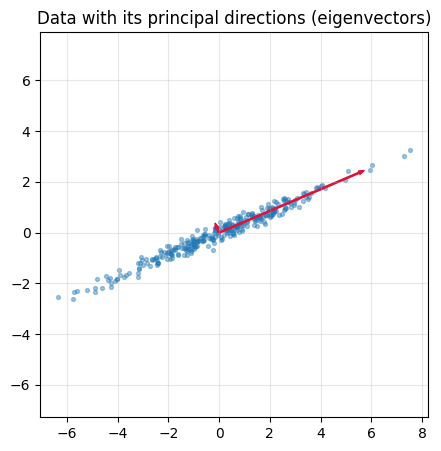

eigenvalues (variance along each direction): [6.2142 0.0274]


In [17]:
# Make correlated 2-D data
pts = rng.normal(size=(300, 2)) @ np.array([[2.0, 0.8],
                                            [0.8, 0.5]])
pts = pts - pts.mean(axis=0)

cov = np.cov(pts.T)                     # 2x2 covariance matrix
vals, vecs = np.linalg.eig(cov)
order = np.argsort(vals)[::-1]          # largest eigenvalue first
vals, vecs = vals[order], vecs[:, order]

plt.figure(figsize=(5, 5))
plt.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.4)
for val, vec in zip(vals, vecs.T):
    plt.arrow(0, 0, *(vec * np.sqrt(val) * 2.5),
              width=0.05, color="crimson", length_includes_head=True)
plt.title("Data with its principal directions (eigenvectors)")
plt.axis("equal"); plt.grid(alpha=0.3); plt.show()
print("eigenvalues (variance along each direction):", vals)

---
## 5. Probability Fundamentals (by simulation)

A probability is a number in $[0, 1]$. Rather than only trusting formulas, we can **simulate**
thousands of trials and watch the empirical frequency approach the true probability.

In [18]:
# P(even) on a fair die
rolls = rng.integers(1, 7, size=100_000)
print("P(even)      ~", np.mean(rolls % 2 == 0))          # ~0.5

# P(sum == 7) for two dice
d1 = rng.integers(1, 7, size=100_000)
d2 = rng.integers(1, 7, size=100_000)
print("P(sum == 7)  ~", np.mean(d1 + d2 == 7))            # ~0.1667 (6/36)

# 'At least one head' in 3 coin flips — via the complement rule (1 - P(none))
flips = rng.integers(0, 2, size=(100_000, 3))             # 1 = head
print("P(>=1 head)  ~", np.mean(flips.sum(axis=1) >= 1))  # ~0.875 (= 7/8)

P(even)      ~ 0.49999
P(sum == 7)  ~ 0.16461


P(>=1 head)  ~ 0.87574


### The law of large numbers, visualised
The running estimate of P(even) wobbles a lot early on, then settles onto the true value 0.5.

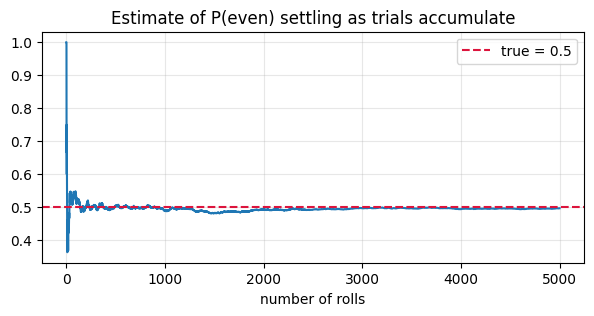

In [19]:
running = np.cumsum(rolls % 2 == 0) / np.arange(1, len(rolls) + 1)
plt.figure(figsize=(7, 3))
plt.plot(running[:5000])
plt.axhline(0.5, color="crimson", ls="--", label="true = 0.5")
plt.title("Estimate of P(even) settling as trials accumulate")
plt.xlabel("number of rolls"); plt.legend(); plt.grid(alpha=0.3); plt.show()

---
## 6. Bayes' Theorem

$$P(A\mid B) = \frac{P(B\mid A)\,P(A)}{P(B)}$$

Update a **prior** belief into a **posterior** using evidence. The classic medical-test result
surprises almost everyone.

In [20]:
def bayes(prior, likelihood, false_alarm):
    # P(disease | positive) given P(disease), P(+|disease), P(+|healthy)
    evidence = likelihood * prior + false_alarm * (1 - prior)
    return likelihood * prior / evidence

# Disease affects 1% of people; test is 99% accurate both ways.
p = bayes(prior=0.01, likelihood=0.99, false_alarm=0.01)
print(f"After ONE positive test: P(sick) = {p:.3f}")   # 0.500 (!)

# Chain a second independent positive: feed the posterior back as the new prior
p2 = bayes(prior=p, likelihood=0.99, false_alarm=0.01)
print(f"After TWO positive tests: P(sick) = {p2:.3f}") # ~0.990

After ONE positive test: P(sick) = 0.500
After TWO positive tests: P(sick) = 0.990


### Watch the base rate matter
The rarer the disease, the more false positives swamp true positives — so the same "99% accurate"
test tells you very different things.

In [21]:
for base_rate in [0.001, 0.01, 0.05, 0.10, 0.30]:
    post = bayes(base_rate, 0.99, 0.01)
    print(f"base rate {base_rate:6.1%}  ->  P(sick | +) = {post:6.1%}")

base rate   0.1%  ->  P(sick | +) =   9.0%
base rate   1.0%  ->  P(sick | +) =  50.0%
base rate   5.0%  ->  P(sick | +) =  83.9%
base rate  10.0%  ->  P(sick | +) =  91.7%
base rate  30.0%  ->  P(sick | +) =  97.7%


---
## 7. Mean, Median, Mode

Where is the centre of the data? **Mean** = average (sensitive to outliers), **median** = middle
(robust), **mode** = most frequent (good for categories).

In [22]:
x = np.array([3, 7, 7, 2, 9, 7, 5])
print("mean  :", np.mean(x))                          # 5.714...
print("median:", np.median(x))                        # 7.0
print("mode  :", stats.mode(x, keepdims=False).mode)  # 7

mean  : 5.714285714285714
median: 7.0
mode  : 7


### Why the median resists outliers
Add one CEO salary to a list of normal salaries and watch the mean get hijacked while the median
barely moves.

In [23]:
salaries = np.array([40, 42, 45, 48, 50])          # in thousands
with_ceo = np.append(salaries, 1000)

print("without CEO -> mean:", np.mean(salaries), " median:", np.median(salaries))
print("with CEO    -> mean:", np.mean(with_ceo),  " median:", np.median(with_ceo))
print("\nThe mean exploded to", round(float(np.mean(with_ceo)), 1),
      "but the median only moved to", np.median(with_ceo))

without CEO -> mean: 45.0  median: 45.0
with CEO    -> mean: 204.16666666666666  median: 46.5

The mean exploded to 204.2 but the median only moved to 46.5


---
## 8. Variance & Standard Deviation

Spread around the mean. **Variance** = average squared distance from the mean.
**Standard deviation** = its square root, back in the original units (the everyday measure of spread).

⚠️ NumPy divides by `n` by default (population). Use `ddof=1` for the sample version (divide by `n-1`).

In [24]:
x = np.array([2, 4, 4, 4, 5, 5, 7, 9])
print("mean               :", np.mean(x))            # 5.0
print("variance (pop, /n) :", np.var(x))             # 4.0
print("std dev  (pop)     :", np.std(x))             # 2.0
print("variance (sample)  :", np.var(x, ddof=1))     # 4.571...

mean               : 5.0
variance (pop, /n) : 4.0
std dev  (pop)     : 2.0
variance (sample)  : 4.571428571428571


### Standardising a feature (mean 0, std 1)
A routine preprocessing step so no feature dominates just because of its units.

In [25]:
z = (x - x.mean()) / x.std()
print("standardised:", z)
print("new mean ~", round(float(z.mean()), 6), "| new std ~", round(float(z.std()), 6))

standardised: [-1.5 -0.5 -0.5 -0.5  0.   0.   1.   2. ]
new mean ~ 0.0 | new std ~ 1.0


#### 🧪 Try it yourself
A feature has mean 100 and std 15. What standardised value (z-score) does a raw value of 130 become?

In [26]:
# Your turn

In [27]:
# Solution
print((130 - 100) / 15)   # 2.0  -> two standard deviations above the mean

2.0


---
## 9. Correlation

Do two variables move together? **Correlation** $r \in [-1, 1]$ measures the strength and direction
of a **linear** relationship. Two warnings: correlation ≠ causation, and $r = 0$ rules out only
*straight-line* relationships.

In [28]:
hours  = np.array([1, 2, 3, 4, 5])
scores = np.array([52, 58, 62, 68, 75])

r = np.corrcoef(hours, scores)[0, 1]
print("correlation r =", round(float(r), 4))   # ~0.995 : strong positive, near-linear

correlation r = 0.9962


### $r = 0$ does not mean "unrelated"
A perfect parabola `y = x²` has correlation ≈ 0, because the relationship is not a straight line.

correlation of t vs t^2: 0.0


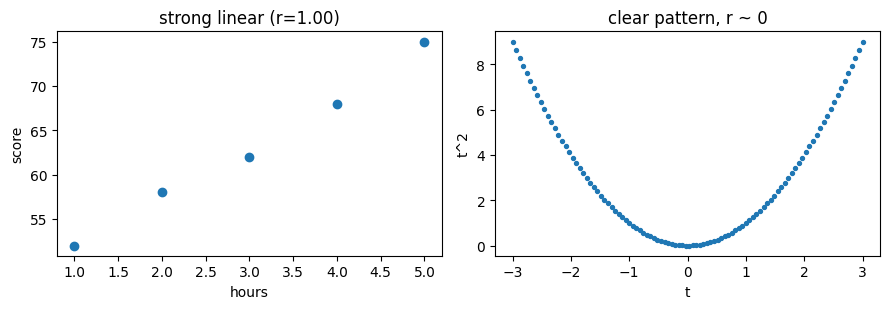

In [29]:
t = np.linspace(-3, 3, 100)
y = t**2
print("correlation of t vs t^2:", round(float(np.corrcoef(t, y)[0, 1]), 4))  # ~0.0

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].scatter(hours, scores); ax[0].set_title(f"strong linear (r={r:.2f})")
ax[0].set_xlabel("hours"); ax[0].set_ylabel("score")
ax[1].scatter(t, y, s=8); ax[1].set_title("clear pattern, r ~ 0")
ax[1].set_xlabel("t"); ax[1].set_ylabel("t^2")
plt.tight_layout(); plt.show()

---
## 10. The Normal Distribution

The bell curve, described by mean $\mu$ (centre) and standard deviation $\sigma$ (width).
The key fact is the **68–95–99.7 rule**: that share of the data lies within 1, 2, 3 standard
deviations of the mean.

In [30]:
samples = rng.normal(170, 10, size=100_000)   # heights: mean 170 cm, std 10 cm
print("sample mean ~", round(float(samples.mean()), 2))
print("sample std  ~", round(float(samples.std()),  2))

for k in (1, 2, 3):
    frac = np.mean(np.abs(samples - 170) <= k * 10)
    print(f"within {k} sd -> {frac:6.2%}")   # ~68%, ~95%, ~99.7%

sample mean ~ 170.0
sample std  ~ 10.0
within 1 sd -> 68.29%
within 2 sd -> 95.48%
within 3 sd -> 99.72%


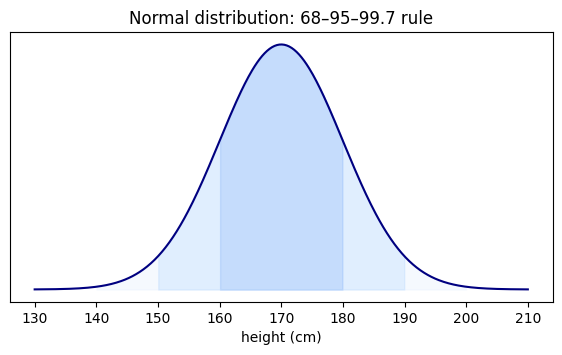

In [31]:
# The bell curve with the 68/95/99.7 bands
mu, sigma = 170, 10
xs = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
pdf = stats.norm.pdf(xs, mu, sigma)

plt.figure(figsize=(7, 3.5))
plt.plot(xs, pdf, color="navy")
for k, c in zip((1, 2, 3), ("#3b82f6", "#93c5fd", "#dbeafe")):
    band = (xs >= mu - k*sigma) & (xs <= mu + k*sigma)
    plt.fill_between(xs[band], pdf[band], alpha=0.25, color=c)
plt.title("Normal distribution: 68–95–99.7 rule")
plt.xlabel("height (cm)"); plt.yticks([]); plt.show()

### z-scores and probabilities
A **z-score** says how many standard deviations a value is from the mean: $z = (x-\mu)/\sigma$.
`stats.norm.cdf` gives the probability of being below a value.

In [32]:
z = (190 - 170) / 10
print("z-score of 190 cm      :", z)                                   # 2.0
print("P(height <= 190) ~", round(float(stats.norm.cdf(190, 170, 10)), 4))  # ~0.977
print("P(height >= 190) ~", round(float(stats.norm.sf(190, 170, 10)), 4))   # ~0.023 (top ~2.5%)

z-score of 190 cm      : 2.0
P(height <= 190) ~ 0.9772
P(height >= 190) ~ 0.0228


---
## 11. Gradients & Gradient Descent

The **gradient** points in the direction of steepest increase; at a minimum it is zero. Models
learn by **gradient descent**: step the weights *against* the gradient of the loss.

$$w_{\text{new}} = w_{\text{old}} - \eta\,\nabla L(w_{\text{old}})$$

where $\eta$ is the **learning rate** (step size).

In [33]:
# Minimise L(w) = w**2. Its gradient is 2*w. True minimum at w = 0.
def loss(w):  return w**2
def grad(w):  return 2 * w

w = 5.0          # starting point
eta = 0.1        # learning rate
history = [w]

for step in range(20):
    w = w - eta * grad(w)     # the gradient-descent update
    history.append(w)

print("final w:", round(w, 5), "(true minimum is 0)")
print("first few w:", [round(v, 3) for v in history[:6]])

final w: 0.05765 (true minimum is 0)
first few w: [5.0, 4.0, 3.2, 2.56, 2.048, 1.638]


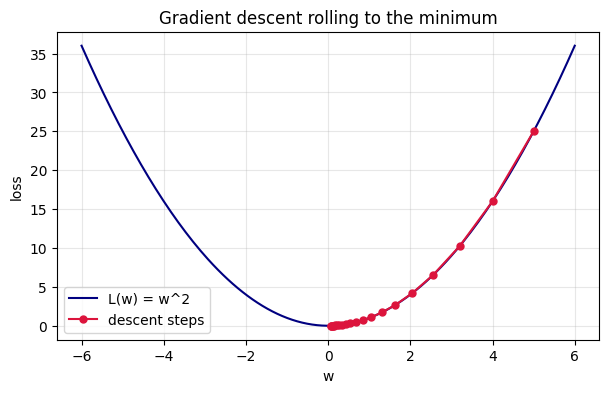

In [34]:
# Visualise the descent walking down the bowl
ws = np.linspace(-6, 6, 200)
plt.figure(figsize=(7, 4))
plt.plot(ws, loss(ws), color="navy", label="L(w) = w^2")
h = np.array(history)
plt.plot(h, loss(h), "o-", color="crimson", ms=5, label="descent steps")
plt.title("Gradient descent rolling to the minimum")
plt.xlabel("w"); plt.ylabel("loss"); plt.legend(); plt.grid(alpha=0.3); plt.show()

### The learning rate is a knob you must tune
Too small → painfully slow. Too large → overshoots and can diverge. Try several and watch.

In [35]:
for eta in [0.01, 0.1, 0.5, 0.9, 1.01]:
    w = 5.0
    for _ in range(15):
        w = w - eta * grad(w)
    tag = "diverges!" if abs(w) > 5 else ""
    print(f"eta = {eta:4.2f}  ->  w after 15 steps = {w:12.4f}  {tag}")

eta = 0.01  ->  w after 15 steps =       3.6928  
eta = 0.10  ->  w after 15 steps =       0.1759  
eta = 0.50  ->  w after 15 steps =       0.0000  
eta = 0.90  ->  w after 15 steps =      -0.1759  
eta = 1.01  ->  w after 15 steps =      -6.7293  diverges!


### Gradient of a multi-input function
For $f(x, y) = x^2 + y^2$ the gradient is $\nabla f = [2x,\ 2y]$. We can also check it numerically
(finite differences) — the same idea libraries use to verify autograd.

In [36]:
def f(v):
    x, y = v
    return x**2 + y**2

def analytic_grad(v):
    x, y = v
    return np.array([2*x, 2*y])

def numeric_grad(f, v, h=1e-5):
    v = np.asarray(v, float)
    g = np.zeros_like(v)
    for i in range(len(v)):
        step = np.zeros_like(v); step[i] = h
        g[i] = (f(v + step) - f(v - step)) / (2 * h)   # central difference
    return g

point = np.array([3.0, 1.0])
print("analytic gradient:", analytic_grad(point))          # [6. 2.]
print("numeric  gradient:", numeric_grad(f, point))        # ~[6. 2.]

analytic gradient: [6. 2.]
numeric  gradient: [6. 2.]


---
## Where to go next

You now have every concept from the book as **living code**. To lock it in:

1. Re-run each section but change the inputs — predict the output first, then verify.
2. Re-implement one thing *without* looking: the Bayes function, or the gradient-descent loop.
3. Combine pieces: standardise a feature (Sec. 8), compute its correlation with a target
   (Sec. 9), then fit a one-variable model by gradient descent (Sec. 11).

*Read a little, compute a lot.*